
  HEAT EQUATION PERFORMANCE COMPARISON

Simulation parameters:
  Rod length: 10m
  Thermal diffusivity: 0.466 m²/s
  Spatial step (dx): 0.1m
  Time step (dt): 0.0001s
  Simulation time: 10s
  Boundary temperatures: 200°C and 200°C

  Stability ratio: k*dt/dx² = 0.0047 ✓ (stable)

Benchmarking: ORIGINAL CODE (Nested For Loops)
Warm-up run...
Run 1/3... 5.1925s
Run 2/3... 5.1860s
Run 3/3... 5.0551s

Results:
  Average time: 5.1445s
  Std deviation: 0.0633s
  Time steps: 100000
  Spatial points: 100

Benchmarking: VECTORIZED CODE (NumPy)
Warm-up run...
Run 1/3... 0.2964s
Run 2/3... 0.3018s
Run 3/3... 0.2878s

Results:
  Average time: 0.2953s
  Std deviation: 0.0058s
  Time steps: 100000
  Spatial points: 100

Benchmarking: CODE WITH NUMBA JIT
Warm-up run...
Run 1/3... 0.0115s
Run 2/3... 0.0215s
Run 3/3... 0.0125s

Results:
  Average time: 0.0152s
  Std deviation: 0.0045s
  Time steps: 100000
  Spatial points: 100

Benchmarking: CODE WITH NUMBA PARALLEL
Warm-up run...
Run 1/3... 0.8228s
R

/var/folders/7r/frrq90jx7_3c7rpx_4nmcg9m0000gn/T/ipykernel_85305/4099913421.py:296: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(methods, rotation=15, ha='right')



✓ Chart saved: performance_comparison.png


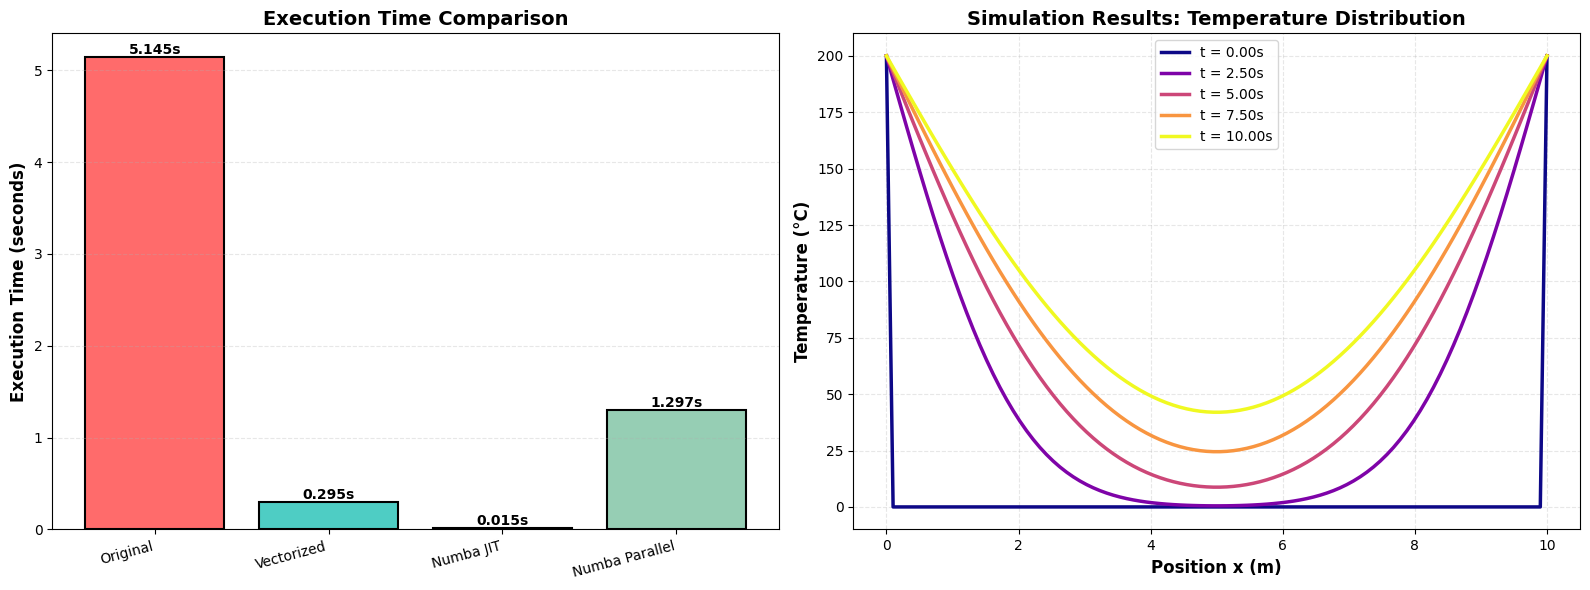

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import jit, prange


# 1. NO NUMBA


def solve_heat_equation_original(length, k, dx, dt, total_time, 
                                 temp_left, temp_right):
    """
    Solve heat equation WITHOUT using Numba
    Uses nested for loops as in original code
    """
    
    x_vec = np.linspace(0, length, int(length/dx))
    t_vec = np.linspace(0, total_time, int(total_time/dt))
    
    
    u = np.zeros((len(t_vec), len(x_vec)))
    
    
    u[:, 0] = temp_left
    u[:, -1] = temp_right
    
    for t in range(len(t_vec) - 1):
        for x in range(1, len(x_vec) - 1):
            u[t+1, x] = (k * (dt / dx**2) * 
                        (u[t, x+1] - 2*u[t, x] + u[t, x-1]) + 
                        u[t, x])
    
    return u, x_vec, t_vec


# 2. NUMPY 

def solve_heat_equation_vectorized(length, k, dx, dt, total_time, 
                                   temp_left, temp_right):
    """
    Solve heat equation using NumPy vectorization
    Eliminates inner for loop
    """
    
    x_vec = np.linspace(0, length, int(length/dx))
    t_vec = np.linspace(0, total_time, int(total_time/dt))
    
    
    u = np.zeros((len(t_vec), len(x_vec)))
    
    
    u[:, 0] = temp_left
    u[:, -1] = temp_right
    
    
    for t in range(len(t_vec) - 1):
        u[t+1, 1:-1] = (k * (dt / dx**2) * 
                        (u[t, 2:] - 2*u[t, 1:-1] + u[t, :-2]) + 
                        u[t, 1:-1])
    
    return u, x_vec, t_vec


# 3. NUMBA

@jit(nopython=True)
def solve_heat_numba_core(u, k, dx, dt, n_time, n_space):
    """
    Core function optimized by Numba JIT
    nopython=True: Fastest mode, no fallback to Python
    """
    for t in range(n_time - 1):
        for x in range(1, n_space - 1):
            u[t+1, x] = (k * (dt / dx**2) * 
                        (u[t, x+1] - 2*u[t, x] + u[t, x-1]) + 
                        u[t, x])
    return u


def solve_heat_equation_numba(length, k, dx, dt, total_time, 
                              temp_left, temp_right):
    """
    Solve heat equation using Numba JIT compilation
    """
    
    x_vec = np.linspace(0, length, int(length/dx))
    t_vec = np.linspace(0, total_time, int(total_time/dt))
    
   
    u = np.zeros((len(t_vec), len(x_vec)))
    
   
    u[:, 0] = temp_left
    u[:, -1] = temp_right
    

    u = solve_heat_numba_core(u, k, dx, dt, len(t_vec), len(x_vec))
    
    return u, x_vec, t_vec


# 4. NUMBA PARALLEL 

@jit(nopython=True, parallel=True)
def solve_heat_numba_parallel_core(u, k, dx, dt, n_time, n_space):
    """
    Core function optimized by Numba with parallelization
    parallel=True: Automatic parallelization of compatible loops
    prange: Parallel range for parallel loops
    """
    for t in range(n_time - 1):
       
        for x in prange(1, n_space - 1):
            u[t+1, x] = (k * (dt / dx**2) * 
                        (u[t, x+1] - 2*u[t, x] + u[t, x-1]) + 
                        u[t, x])
    return u


def solve_heat_equation_numba_parallel(length, k, dx, dt, total_time, 
                                      temp_left, temp_right):
    """
    Solve heat equation using Numba with parallelization
    """
    
    x_vec = np.linspace(0, length, int(length/dx))
    t_vec = np.linspace(0, total_time, int(total_time/dt))
    
    
    u = np.zeros((len(t_vec), len(x_vec)))
    
   
    u[:, 0] = temp_left
    u[:, -1] = temp_right
    
   
    u = solve_heat_numba_parallel_core(u, k, dx, dt, len(t_vec), len(x_vec))
    
    return u, x_vec, t_vec




def benchmark_solver(solver_func, name, length, k, dx, dt, total_time, 
                    temp_left, temp_right, num_runs=3):
    """
    Measure execution time of a solver
    
    Parameters:
    -----------
    solver_func : function
        Solver function to benchmark
    name : str
        Name of the solver
    num_runs : int
        Number of runs to average
    """
    print(f"\n{'='*60}")
    print(f"Benchmarking: {name}")
    print(f"{'='*60}")
    
    times = []
    
   
    print("Warm-up run...")
    _ = solver_func(length, k, dx, dt, total_time, temp_left, temp_right)
    
    
    for run in range(num_runs):
        print(f"Run {run + 1}/{num_runs}...", end=" ")
        
        start_time = time.time()
        u, x_vec, t_vec = solver_func(length, k, dx, dt, total_time, 
                                      temp_left, temp_right)
        end_time = time.time()
        
        elapsed = end_time - start_time
        times.append(elapsed)
        print(f"{elapsed:.4f}s")
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    
    print(f"\nResults:")
    print(f"  Average time: {avg_time:.4f}s")
    print(f"  Std deviation: {std_time:.4f}s")
    print(f"  Time steps: {len(t_vec)}")
    print(f"  Spatial points: {len(x_vec)}")
    
    return avg_time, u, x_vec, t_vec


def compare_all_methods(length=10, k=0.466, dx=0.1, dt=0.0001, 
                       total_time=10, temp_left=200, temp_right=200):
    """
    results
    """
    print("\n" + "="*70)
    print("  HEAT EQUATION PERFORMANCE COMPARISON")
    print("="*70)
    
    print(f"\nSimulation parameters:")
    print(f"  Rod length: {length}m")
    print(f"  Thermal diffusivity: {k} m²/s")
    print(f"  Spatial step (dx): {dx}m")
    print(f"  Time step (dt): {dt}s")
    print(f"  Simulation time: {total_time}s")
    print(f"  Boundary temperatures: {temp_left}°C and {temp_right}°C")
    
    # Check stability condition
    stability_ratio = k * dt / dx**2
    print(f"\n  Stability ratio: k*dt/dx² = {stability_ratio:.4f}", end="")
    if stability_ratio <= 0.5:
        print(" ✓ (stable)")
    else:
        print(" ✗ (unstable!)")
    
    results = {}
    
    
    time_original, u1, x1, t1 = benchmark_solver(
        solve_heat_equation_original,
        "ORIGINAL CODE (Nested For Loops)",
        length, k, dx, dt, total_time, temp_left, temp_right
    )
    results['Original'] = time_original
    
   
    time_vectorized, u2, x2, t2 = benchmark_solver(
        solve_heat_equation_vectorized,
        "VECTORIZED CODE (NumPy)",
        length, k, dx, dt, total_time, temp_left, temp_right
    )
    results['Vectorized'] = time_vectorized
    
   
    time_numba, u3, x3, t3 = benchmark_solver(
        solve_heat_equation_numba,
        "CODE WITH NUMBA JIT",
        length, k, dx, dt, total_time, temp_left, temp_right
    )
    results['Numba JIT'] = time_numba
    
    
    time_numba_parallel, u4, x4, t4 = benchmark_solver(
        solve_heat_equation_numba_parallel,
        "CODE WITH NUMBA PARALLEL",
        length, k, dx, dt, total_time, temp_left, temp_right
    )
    results['Numba Parallel'] = time_numba_parallel
    
    # Sum
    print("\n" + "="*70)
    print("  SUMMARY OF RESULTS")
    print("="*70)
    
    baseline = time_original
    
    print(f"\n{'Method':<25} {'Time (s)':<15} {'Speedup':<15}")
    print("-"*70)
    
    for name, time_val in results.items():
        speedup = baseline / time_val
        print(f"{name:<25} {time_val:>10.4f}s     {speedup:>8.2f}x")
    
    # Plot Compare 
    plot_comparison(results, u1, x1, t1)
    
    return results, u1, x1, t1


def plot_comparison(results, u, x_vec, t_vec):
    """
    Plot execution time comparison and simulation results
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart 
    methods = list(results.keys())
    times = list(results.values())
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    bars = ax1.bar(methods, times, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_title('Execution Time Comparison', fontsize=14, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{time_val:.3f}s',
                ha='center', va='bottom', fontweight='bold')
    
    
    ax1.set_xticklabels(methods, rotation=15, ha='right')
    
   
    time_indices = [0, 
                   int(0.25 * (len(t_vec) - 1)),
                   int(0.50 * (len(t_vec) - 1)),
                   int(0.75 * (len(t_vec) - 1)),
                   len(t_vec) - 1]
    
    colors_temp = plt.cm.plasma(np.linspace(0, 1, len(time_indices)))
    
    for idx, color in zip(time_indices, colors_temp):
        label = f"t = {t_vec[idx]:.2f}s"
        ax2.plot(x_vec, u[idx, :], lw=2.5, label=label, color=color)
    
    ax2.set_xlabel('Position x (m)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
    ax2.set_title('Simulation Results: Temperature Distribution', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
    print("\n✓ Chart saved: performance_comparison.png")
    plt.show()



# MAIN


if __name__ == "__main__":
    # Run comparison with original code
    results, u, x_vec, t_vec = compare_all_methods(
        length=10,
        k=0.466,
        dx=0.1,
        dt=0.0001,
        total_time=10,
        temp_left=200,
        temp_right=200
    )
    
    print("\n" + "="*70)
    print("="*70)

Execution time evaluation.

The experimental results reveal a dramatic improvement in execution time when applying Numba to the 1D Heat Equation simulation. 

Specifically, the execution time decreased from 5.145 seconds (pure Python loops) to 0.0152 seconds using Numba JIT compilation. 

This corresponds to an impressive 339× performance speedup.

NUMBA IS GREAT CHOICE : 
Just-In-Time (JIT) Compilation
Numba translates Python functions into optimized machine code at runtime, eliminating interpretation overhead.
Elimination of Python Overhead
Python’s dynamic features (type checking, object creation, reference counting) are bypassed in nopython mode, resulting in much faster loop execution.
LLVM Compiler Optimizations
Numba leverages the LLVM infrastructure to apply aggressive low-level optimizations unavailable to pure Python code.
Loop Optimization at Native Speed
The nested loops in the heat equation update step are executed at native CPU speed instead of Python’s slower bytecode execution.

This evaluation shows that Numba provides exceptional performance benefits for numerical simulations written in Python. 

By adding only a single decorator (@jit(nopython=True)), the execution time of the heat equation solver was reduced from 5.145 seconds to 0.0152 seconds, achieving a 339× speedup with minimal code modification.

